In [1]:
import torch
from torchvision import datasets, transforms
from tqdm import tqdm

In [3]:
gen_transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5071, 0.4867, 0.4408),
        std=(0.2675, 0.2565, 0.2761)
    ) # this is CIFAR 100 specific normalization, so no one channel dominates gradients. It comes from a formula but explore that in depth later
])

train_transformer = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5071, 0.4867, 0.4408),
        std=(0.2675, 0.2565, 0.2761)
    ) # this is CIFAR 100 specific normalization, so no one channel dominates gradients. It comes from a formula but explore that in depth later
])

In [4]:
from torch.utils.data import Subset
from collections import Counter # useful to check for class imbalance

train_data = datasets.CIFAR100(
    root = './data',
    train = True,
    transform = train_transformer,
    download = True
)

# checking for class imbalance
classes = train_data.targets # targets property is not applicable on train_data from here on out as it is of type Subset
class_counts = Counter(classes)
for cls in range(100):
    print(f"Class {cls}: {class_counts[cls]} samples")
# print(classes)

train_data = Subset(train_data, range(0, 45000))

val_data = datasets.CIFAR100(
    root = './data',
    train = True,
    transform = gen_transformer,
    download = True
)
val_data = Subset(val_data, range(45000, 50000))
# train_data, val_data = random_split(train_and_val_data, [45000, 5000]) # total training data is 50k, splitting it for validation purposes

test_data = datasets.CIFAR100(
    root = './data',
    train = False,
    transform = gen_transformer,
    download = True
)

100%|██████████| 169M/169M [00:03<00:00, 43.6MB/s]


Class 0: 500 samples
Class 1: 500 samples
Class 2: 500 samples
Class 3: 500 samples
Class 4: 500 samples
Class 5: 500 samples
Class 6: 500 samples
Class 7: 500 samples
Class 8: 500 samples
Class 9: 500 samples
Class 10: 500 samples
Class 11: 500 samples
Class 12: 500 samples
Class 13: 500 samples
Class 14: 500 samples
Class 15: 500 samples
Class 16: 500 samples
Class 17: 500 samples
Class 18: 500 samples
Class 19: 500 samples
Class 20: 500 samples
Class 21: 500 samples
Class 22: 500 samples
Class 23: 500 samples
Class 24: 500 samples
Class 25: 500 samples
Class 26: 500 samples
Class 27: 500 samples
Class 28: 500 samples
Class 29: 500 samples
Class 30: 500 samples
Class 31: 500 samples
Class 32: 500 samples
Class 33: 500 samples
Class 34: 500 samples
Class 35: 500 samples
Class 36: 500 samples
Class 37: 500 samples
Class 38: 500 samples
Class 39: 500 samples
Class 40: 500 samples
Class 41: 500 samples
Class 42: 500 samples
Class 43: 500 samples
Class 44: 500 samples
Class 45: 500 sample

In [5]:
print(len(train_data))
print(len(test_data))
print(len(val_data))

45000
10000
5000


In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_data, batch_size = 32, shuffle = False)
test_loader = DataLoader(test_data, batch_size = 32, shuffle = False)

torch.Size([3, 32, 32])


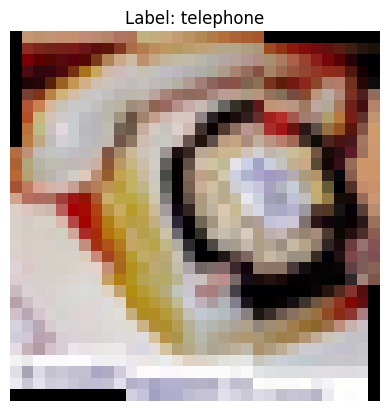

In [7]:
# plotting 1 image
import matplotlib.pyplot as plt

image, label = train_data[5]
print(image.shape)

image_np = image.permute(1, 2, 0) # matplot want dimensions in the format of (H, W, C), but we have it in format of (C, H, W) by default

# print(train_data.dataset.classes[label])

# undoing normalization
mean = torch.tensor([0.5071, 0.4867, 0.4408])
std  = torch.tensor([0.2675, 0.2565, 0.2761])
image_np = image_np * std + mean
image_np = image_np.clamp(0, 1)

plt.imshow(image_np)
plt.title(f"Label: {train_data.dataset.classes[label]}")
plt.axis("off")
plt.show()


In [31]:
import torch.nn as nn
class CIFAR100_CNN(nn.Module):
    def __init__(self):
      super().__init__()

      self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, stride = 1, padding = 1)
      self.bn1 = nn.BatchNorm2d(32)

      self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, stride = 1, padding = 1)
      self.bn2 = nn.BatchNorm2d(64)

      self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, stride = 1, padding = 1)
      self.bn3 = nn.BatchNorm2d(128)

      self.conv4 = nn.Conv2d(128, 256, kernel_size = 3, stride = 1, padding = 1)
      self.bn4 = nn.BatchNorm2d(256)


      self.pool = nn.MaxPool2d(2, 2)
      self.dropout = nn.Dropout(0.15)


      # self.fc1 = nn.Linear(16384, 1024) # Logic for 1024 below
      # -- fuck the fc1 layer - modern CNNs don't really do that anymore -> Use global average pooling
      self.gap = nn.AdaptiveAvgPool2d(1)
      self.fc2 = nn.Linear(256, 100) # because there are 100 classes in CIFAR 100 - obvious?

    def forward(self, x):
      x = self.bn1(torch.relu(self.conv1(x)))
      x = self.pool(self.bn2(torch.relu(self.conv2(x))))
      x = self.bn3(torch.relu(self.conv3(x)))
      x = self.pool(self.bn4(torch.relu(self.conv4(x))))

      # x = torch.flatten(x, 1) # -- fuck this shit too
      # print(f'Flattened: {x.shape}') # use this line + the dummy run to find out how many input features to give for fc1 !! IMPORTANT !!
      # x = torch.relu(self.fc1(x))

      x = self.gap(x)
      x = x.view(x.size(0), -1) # similar to flattening but retains batching - not really sure what the fuck it means but yes.
      # x = self.dropout(x) # enable this later
      x = self.fc2(x)

      return x





In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [33]:
model = CIFAR100_CNN().to(device)
dummy = torch.zeros(1, 3, 32, 32)
out = model(dummy.to(device))  # Dummy run to find out the shape after flattening the output from the final conv layer

In [34]:
def train_loop(model, optimizer, train_loader, lossFn, device, epoch):
  model.train()
  curr_train_loss = 0
  correct = 0
  total = 0

  # === Training ===
  print()
  for X, y in tqdm(train_loader, desc = f'Epoch: {epoch + 1} - Training'):
    X = X.to(device)
    y = y.to(device)
    # print(y.shape)

    optimizer.zero_grad()

    yhat = model(X)
    # print(yhat.shape)

    loss = lossFn(yhat, y)

    loss.backward()

    optimizer.step()

    curr_train_loss += loss.item() * X.size(0)
    _, predicted = yhat.max(1)
    correct += predicted.eq(y).sum().item()
    total += y.size(0)
  epoch_train_loss = curr_train_loss / total
  epoch_train_acc = correct / total

  return epoch_train_loss, epoch_train_acc


In [35]:
def val_loop(model, optimizer, val_loader, lossFn, device, epoch):
  model.eval()
  curr_val_loss = 0
  correct = 0
  total = 0

  # === Validation ===
  with torch.no_grad():
    for X, y in tqdm(val_loader, desc = f'Epoch: {epoch + 1} - Validating'):
      X = X.to(device)
      y = y.to(device)

      yhat = model(X)

      loss = lossFn(yhat, y)

      curr_val_loss += loss.item() * X.size(0)

      _, preds = torch.max(yhat, dim = 1)

      correct += (preds == y).sum().item()
      total += y.size(0)

  epoch_val_loss = curr_val_loss / total
  epoch_val_acc = correct / total

  return epoch_val_loss, epoch_val_acc

In [36]:
import torch.optim as optim


# training loop

epochs = 20
lossFn = nn.CrossEntropyLoss(label_smoothing = 0.1)
optimizer = optim.AdamW(model.parameters(), lr = 0.0003, weight_decay = 0.0001)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max = epochs
)

val_loss = []
train_loss = []
val_accuracy = []
train_accuracy = []

for epoch in range(epochs):
  epoch_train_loss, epoch_train_accuracy = train_loop(model, optimizer, train_loader, lossFn, device, epoch)
  train_loss.append(epoch_train_loss)
  train_accuracy.append(epoch_train_accuracy)

  epoch_val_loss, epoch_val_accuracy = val_loop(model, optimizer, test_loader, lossFn, device, epoch)
  val_loss.append(epoch_val_loss)
  val_accuracy.append(epoch_val_accuracy)

  scheduler.step(epoch_val_loss)



print(f'\ntrain_loss: {train_loss}'
      f'\nval_loss: {val_loss}')



Epoch: 1 - Validating: 100%|██████████| 313/313 [00:03<00:00, 103.49it/s]
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:204: UserWarning:

The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.



Epoch: 2 - Validating: 100%|██████████| 313/313 [00:03<00:00, 87.87it/s] 


Epoch: 3 - Validating: 100%|██████████| 313/313 [00:03<00:00, 102.32it/s]


Epoch: 4 - Validating: 100%|██████████| 313/313 [00:03<00:00, 99.95it/s]


Epoch: 5 - Validating: 100%|██████████| 313/313 [00:03<00:00, 86.77it/s] 


...

Epoch: 17 - Validating: 100%|██████████| 313/313 [00:03<00:00, 94.10it/s] 


Epoch: 18 - Validating: 100%|██████████| 313/313 [00:03<00:00, 101.89it/s]


Epoch: 19 - Validating: 100%|██████████| 313/313 [00:03<00:00, 101.52it/s]


Epoch: 20 - Validating: 100%|██████████| 313/313 [00:03<00:00, 90.52it/s]


train_loss: [3.8119879046969944, 3.266147611236572, 2.979981760152181, 2.7867580051845975, 2.6459725612216527, 2.536148495695326, 2.444987034479777, 2.373411378648546, 2.310043831676907, 2.2515848134358722, 2.204166326649984, 2.155810324605306, 2.118392731942071, 2.083660768975152, 2.0517900789048937, 2.0131799265967474, 1.98503270840115, 1.961788452190823, 1.9351949442545573, 1.9100833286709256]
val_loss: [3.4188498039245605, 3.0543004398345945, 2.860335525894165, 2.6996681453704836, 2.5977820137023926, 2.518938835144043, 2.4685931427001955, 2.414927456283569, 2.3921115501403807, 2.345943928146362, 2.3469675441741944, 2.3117339557647707, 2.310762210083008, 2.2919281089782717, 2.283136057281494, 2.260939936065674, 2.2565227436065673, 2.2567567756652833, 2.2530719440460203, 2.2520662574768067]


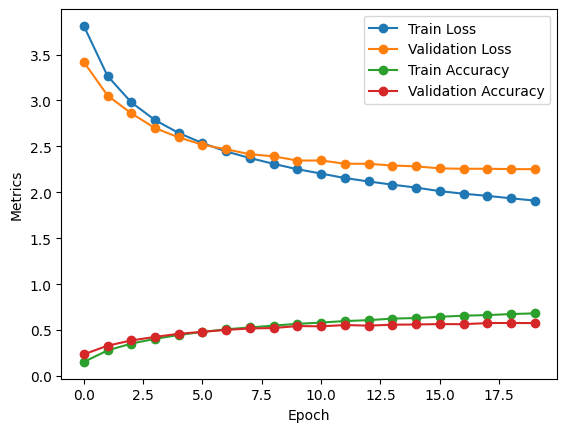

In [37]:
plt.plot(train_loss, 'o-', label = 'Train Loss')
plt.plot(val_loss, 'o-', label = 'Validation Loss')
plt.plot(train_accuracy, 'o-', label = 'Train Accuracy')
plt.plot(val_accuracy, 'o-', label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.legend()
plt.show()

In [38]:
import plotly.express as px

epochs = list(range(1, len(train_loss) + 1))

fig = px.line(
    x = epochs,
    y = [train_loss, val_loss, train_accuracy, val_accuracy],
    labels = {"x": "Epoch", "value": "Metrics"},
    markers = True
)

fig.data[0].name = "Train Loss"
fig.data[1].name = "Validation Loss"
fig.data[2].name = "Train Accuracy"
fig.data[3].name = "Validation Accuracy"

fig.show()

In [39]:
# testing

test_loss = 0.0
correct = 0
total = len(test_data)

with torch.no_grad():
  for X, y in tqdm(test_loader, desc = f'Testinggggg: '):
    X = X.to(device)
    y = y.to(device)

    yhat = model(X)

    loss = lossFn(yhat, y)

    test_loss += loss.item() * X.size(0)

    _, preds = torch.max(yhat, dim = 1)

    correct += (preds == y).sum().item()


accuracy = correct / total * 100

Testinggggg: 100%|██████████| 313/313 [00:03<00:00, 86.65it/s]


In [40]:
accuracy

57.60999999999999

In [17]:
from collections import Counter
# classes = train_data.targets
type(train_data)

torch.utils.data.dataset.Subset